In [36]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from scipy.interpolate import interp1d
from statsmodels.nonparametric.kernel_regression import KernelReg
from tools import *

In [49]:
df = pd.read_csv('/Users/kellyhui/Downloads/RBG_data/RBG_3_102425.csv')
df = clean_and_transpose(df, 31, 129)
df

Series,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
Time [s],,,,,,,,,,,,,,,,,,,,,
0.000000,0.2140,0.2044,0.2083,0.1965,0.2090,0.1970,0.1851,0.1917,0.1943,0.2013,...,0.0999,0.0982,0.0972,0.0989,0.0985,0.0991,0.1011,0.0999,0.1021,0.1009
0.250028,0.2228,0.2114,0.1899,0.2021,0.2096,0.2089,0.1969,0.2056,0.2157,0.2032,...,0.1038,0.0986,0.0976,0.0975,0.0989,0.0997,0.1012,0.0999,0.1015,0.1007
0.500056,0.2237,0.2184,0.1981,0.2012,0.2133,0.2057,0.1946,0.2058,0.2023,0.2025,...,0.1037,0.0983,0.0972,0.0974,0.0984,0.0992,0.1009,0.0995,0.1011,0.1003
0.750083,0.2159,0.2093,0.1973,0.2056,0.2073,0.2067,0.1984,0.2043,0.1972,0.1961,...,0.1032,0.0983,0.0974,0.0976,0.0984,0.0993,0.1009,0.0997,0.1010,0.1003
1.000111,0.2085,0.2058,0.2031,0.2046,0.2092,0.2049,0.1905,0.1948,0.1933,0.1922,...,0.1029,0.0979,0.0970,0.0975,0.0980,0.0987,0.1005,0.0991,0.1007,0.0999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34.753361,0.9137,0.8578,0.9380,0.9001,0.8384,0.8353,0.9211,0.7984,0.8270,0.7441,...,0.1017,0.0978,0.0958,0.0965,0.0967,0.0973,0.0987,0.0976,0.0993,0.0988
35.003361,0.9068,0.8437,0.9375,0.9155,0.8434,0.8386,0.9207,0.7998,0.8277,0.7443,...,0.1017,0.0977,0.0958,0.0964,0.0967,0.0973,0.0989,0.0976,0.0990,0.0988
35.253389,0.9265,0.8509,0.9237,0.9025,0.8541,0.8409,0.9392,0.8068,0.8307,0.7466,...,0.1017,0.0979,0.0960,0.0970,0.0968,0.0976,0.0990,0.0977,0.0994,0.0989


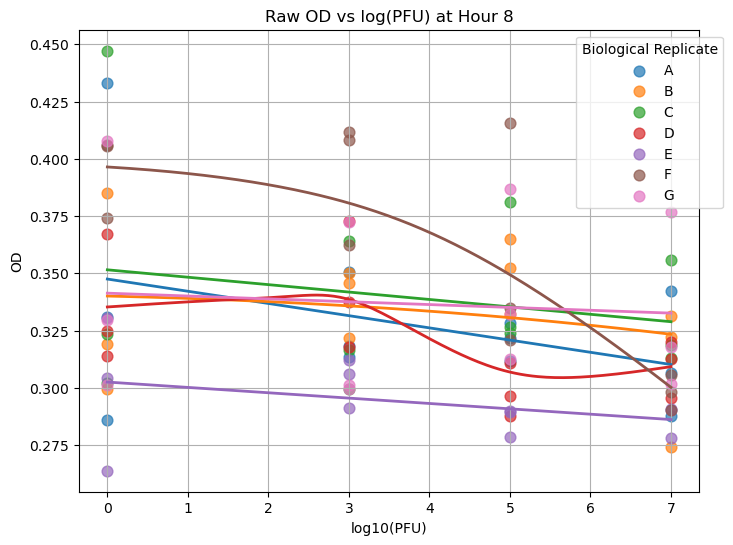

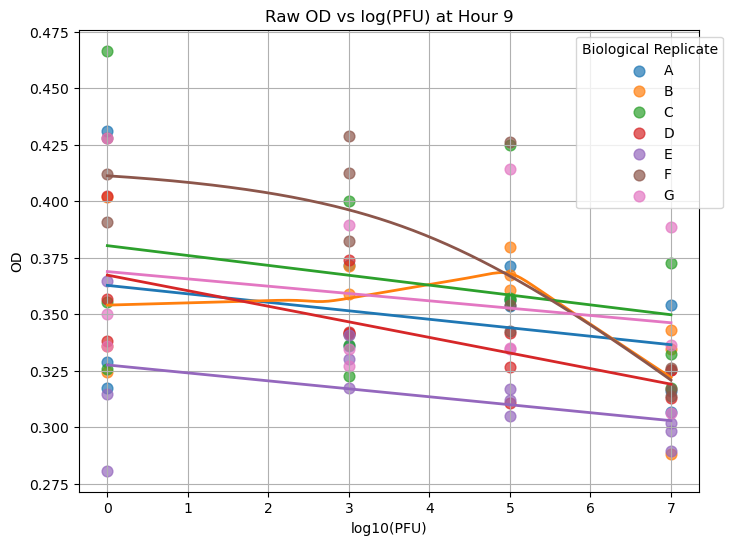

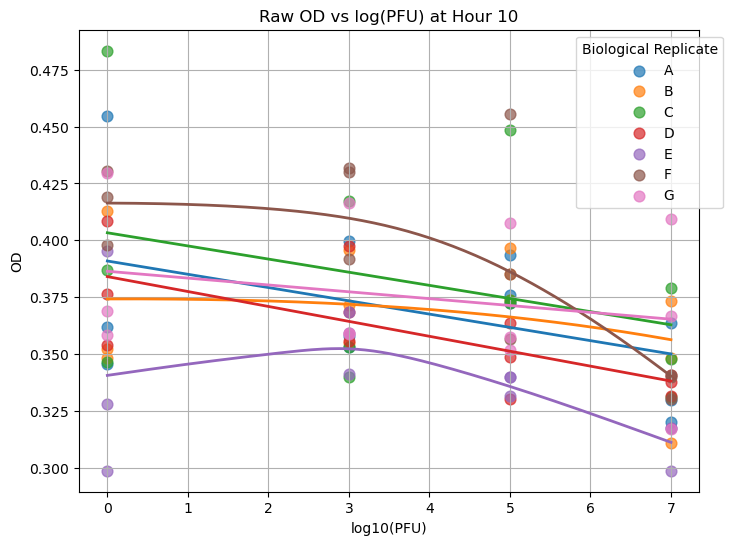

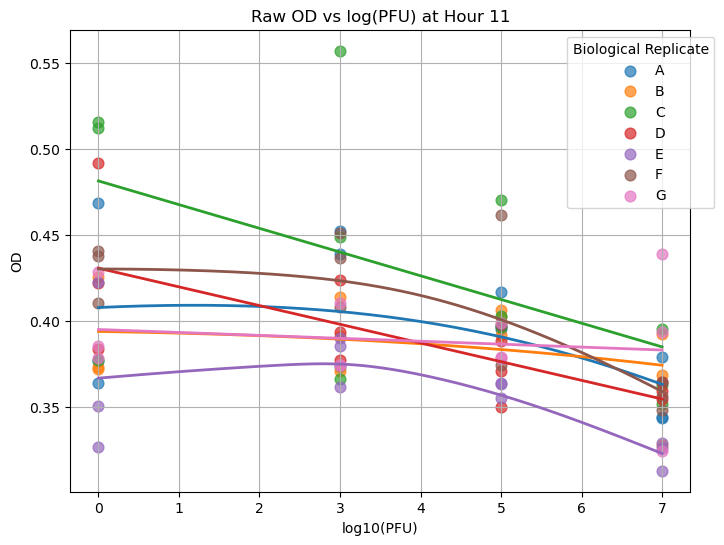

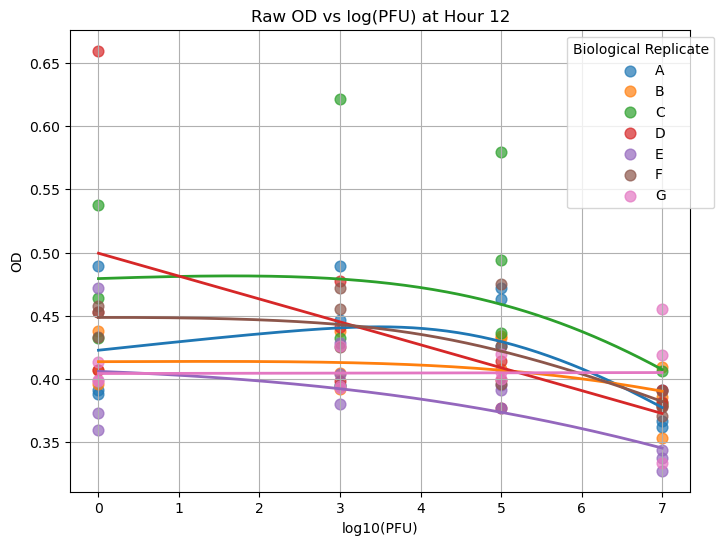

,A,B,C,D,E,F,G
8,3.517588,4.643216,3.482412,3.939698,3.517588,5.065327,3.517588
9,3.517588,6.015075,3.517588,3.482412,3.517588,5.030151,3.482412
10,3.482412,5.276382,3.482412,3.517588,5.346734,5.417085,3.482412
11,5.417085,4.819095,3.517588,3.482412,5.522613,5.346734,3.482412
12,5.944724,5.768844,5.733668,3.482412,4.819095,5.381910,3.482412


In [69]:
df.index = np.round(df.index).astype(int)
df_hourly = df.loc[df.index.isin(range(0, 16))]
df_hourly = df_hourly.groupby(df_hourly.index).first()

x_vals = [0, 3, 5, 7]
bio_reps = list(string.ascii_uppercase)[:7] #A-H

ic50_table = pd.DataFrame(index=range(8,13), columns=bio_reps, dtype=float)

for hour in range(8, 13):
    if hour not in df_hourly.index:
        continue
        
    plt.figure(figsize=(8, 6))

    for letter in bio_reps:
        table = df_hourly.filter(regex = rf'^{letter}')
        if table.empty:
            continue
            
        y_vals = table.loc[hour].values
        
        
        x_repeat = np.repeat(x_vals, 3)
            
        plt.scatter(x_repeat, y_vals, label=letter, s=60, alpha=0.7)
        
       # Fit kernel regression
        kr = KernelReg(endog=y_vals, exog=x_repeat, var_type='c', reg_type='ll')
        
        # Smooth prediction
        x_grid = np.linspace(min(x_repeat), max(x_repeat), 200)
        y_pred_grid, _ = kr.fit(x_grid)
        
        # Half-max from smooth curve
        half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2
        
        # Find IC50
        idx = np.argmin(np.abs(y_pred_grid - half_max))
        ic50 = x_grid[idx]
        
        # Store in table
        ic50_table.loc[hour, letter] = ic50
        
        # Plot smooth curve
        plt.plot(x_grid, y_pred_grid, lw=2)

        
        
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(f'Raw OD vs log(PFU) at Hour {hour}')
    plt.legend(title='Biological Replicate', bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.show()
    
ic50_table
        

In [70]:
# smooth curve
x_grid = np.linspace(min(x_repeat), max(x_repeat), 200)
y_pred_grid, _ = kr.fit(x_grid)

# half-max from smoothed curve
half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2

# IC50 = x where curve crosses half-max
idx = np.argmin(np.abs(y_pred_grid - half_max))
ic50 = x_grid[idx]
ic50

np.float64(3.4824120603015074)

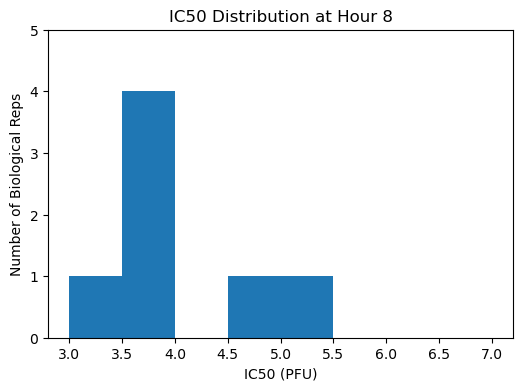

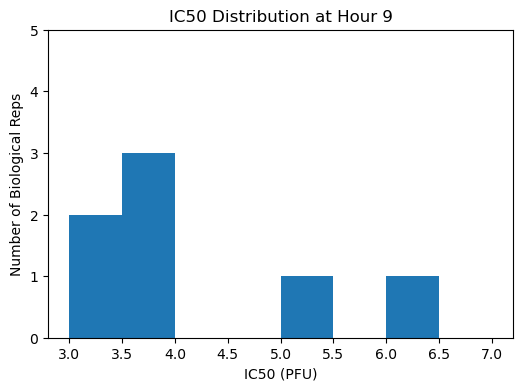

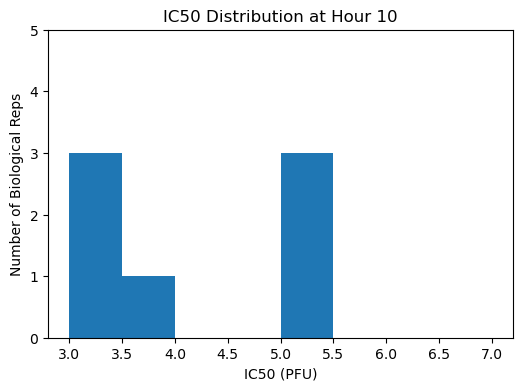

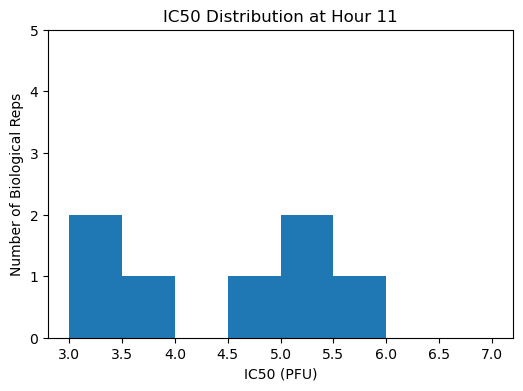

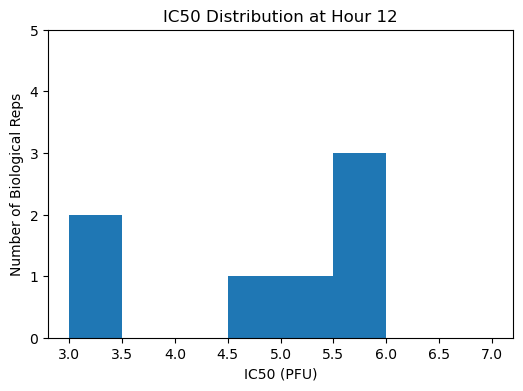

In [72]:
for hour in range(8,13):
    ic50_values = ic50_table.loc[hour].values
    plt.figure(figsize=(6,4))
    plt.hist(ic50_values, bins = 8, range = (3, 7))
    plt.ylim(0, 5) 
    plt.xlabel('IC50 (PFU)')
    plt.ylabel('Number of Biological Reps')
    plt.title(f'IC50 Distribution at Hour {hour}')